## Import the necessary functions 

In [1]:
# Import the necessary functions

# Personalised functions created for this NN application
from NEMO_NN_functions import *
# To convert from lat lon, to x y
from pyproj import Transformer
# To extract just the bedmachine mask within the NEMO 1 degree grid 
from shapely.geometry import Polygon
from shapely.vectorized import contains
# To extract neighbouring cells
from scipy.ndimage import binary_dilation 
# To plot figures 
import matplotlib.pyplot as plt

# To create the ocean profile 
from scipy.spatial import cKDTree

## Set variables 

In [2]:
# Set the filepaths and any variables 

# NEMO simulation temperature and salinity profiles 
filepath_nemo_output = '/bettik/ockendeh/SCRIPTS/simpleNN_basal_melt/AIAI_data/ECM71-ico-LR-pi-01.pi_1883_1Y_grid_T.nc'
#filepath_nemo_output = '/bettik/ockendeh/NEMO_simulations/TGCC/eORCA1.L75-TOTO_y1985.1y_gridT.nc'
#filepath_nemo_output = '/bettik/ockendeh/NEMO_simulations/TGCC/eORCA1.L75-TOTO_1y_NN_1979-1979.nc'

# NEMO full grid coords
filepath_domain_cfg = '/bettik/ockendeh/NEMO_simulations/TGCC/eORCA1.4.3_CavsForNN_domain_cfg.nc'

# Set the filepaths 
# The target grid mask 
filepath_mask = '/bettik/ockendeh/NEMO_simulations/NEMO025_bmach_geometric_masks.nc'
# The target grid geometry
filepath_geomvars = '/bettik/ockendeh/NEMO_simulations/NEMO025_bmach_geom_vars.nc'
# The eORCA1 bedmachine mask
filepath_eORCA1_bmach_masks = '/bettik/ockendeh/NEMO_simulations/eORCA1_bmach_masks.nc'

# Neural network filepaths 
path_model = '/bettik/ockendeh/NEMO_simulations/models/'
path_model = '/bettik/ockendeh/SCRIPTS/simpleNN_basal_melt/AIAI_data/NN_models/'
path_norm_metrics = '/bettik/ockendeh/NEMO_simulations/models/'
path_norm_metrics = '/bettik/ockendeh/SCRIPTS/simpleNN_basal_melt/AIAI_data/Training_data/'

# And the location of the output files 
folder_nn_output = '/bettik/ockendeh/SCRIPTS/simpleNN_basal_melt/data/processing_ho/'
simulation = 'DUM002' # Can potentially be set from the input 
year_of_interest = '9999' # Can potentially be set from the input 
filepath_nn_output = folder_nn_output + 'nn_output_melt' '_' + simulation + '_' + year_of_interest + '.nc'

# Any parameters which need to be set 
# Which neural network have you chosen?
this_collection = 'OPM026_OPM0263_OPM031_OPM016_OPM018_OPM021_ctrl94_isf94_isfru94'
#this_collection = 'OPM026'
exp_name = 'slope_front'
join_ice_shelves = False
nemo_version = '5'

In [3]:
#fp_old_geomvars = '/bettik/ockendeh/SCRIPTS/simpleNN_basal_melt/AIAI_data/Masks/OPM026_geom_vars.nc'
fp_old_geomvars = '/bettik/ockendeh/SCRIPTS/simpleNN_basal_melt/AIAI_data/Masks/OPM026_geom_vars_frac1.nc'
fp_old_mask = '/bettik/ockendeh/SCRIPTS/simpleNN_basal_melt/AIAI_data/Masks/OPM026_geometric_masks_newbasins.nc'
#fp_old_mask = '/bettik/ockendeh/SCRIPTS/simpleNN_basal_melt/AIAI_data/Masks/OPM026_geometric_masks.nc'

In [4]:
make_old_mask_new_basins = False
if make_old_mask_new_basins == True:
    old_mask = xr.open_dataset(fp_old_mask)
    new_mask = xr.open_dataset(filepath_mask)
    old_mask2 = old_mask.copy()
    old_mask2['basins_NEMO'] = new_mask.basins_NEMO
    old_mask2.to_netcdf('/bettik/ockendeh/SCRIPTS/simpleNN_basal_melt/AIAI_data/Masks/OPM026_geometric_masks_newbasins.nc')
    old_geom_frac = old_geomvars.copy()
    old_geom_frac['fraction'] = old_geom_frac.lat*0 +1
    old_geom_frac.to_netcdf('/bettik/ockendeh/SCRIPTS/simpleNN_basal_melt/AIAI_data/Masks/OPM026_geom_vars_frac1.nc')

In [6]:
old_mask = xr.open_dataset(fp_old_mask)
new_mask = xr.open_dataset(filepath_mask)
old_geomvars = xr.open_dataset(fp_old_geomvars)
new_geomvars = xr.open_dataset(filepath_geomvars)

In [7]:
make_old_mask_new_basins = False
if make_old_mask_new_basins == True:
    old_geom_dists = old_geomvars.copy()
    old_geom_dists['distances_GL'] = new_geomvars.distances_GL
    old_geom_dists['distances_OO'] = new_geomvars.distances_OO
    old_geom_dists['distances_OC'] = new_geomvars.distances_OC
    old_geom_dists.to_netcdf('/bettik/ockendeh/SCRIPTS/simpleNN_basal_melt/AIAI_data/Masks/OPM026_geom_vars_dists.nc')

In [8]:
make_old_mask_new_basins = False
if make_old_mask_new_basins == True:
    old_geom_bathy = old_geomvars.copy()
    old_geom_bathy['bathymetry'] = new_geomvars.bathymetry
    old_geom_bathy['slope_bathy_lon'] = new_geomvars.slope_bathy_lon
    old_geom_bathy['slope_bathy_lat'] = new_geomvars.slope_bathy_lat
    old_geom_bathy['slope_ba_across_front'] = new_geomvars.slope_ba_across_front
    old_geom_bathy['slope_ba_towards_front'] = new_geomvars.slope_ba_towards_front
    old_geom_bathy.to_netcdf('/bettik/ockendeh/SCRIPTS/simpleNN_basal_melt/AIAI_data/Masks/OPM026_geom_vars_bathy.nc')

In [41]:
make_old_mask_new_basins = True
if make_old_mask_new_basins == True:
    old_geom_isfdt = old_geomvars.copy()
    old_geom_isfdt['isf_draft'] = new_geomvars.isf_draft
    old_geom_isfdt['slope_isdraft_lon'] = new_geomvars.slope_isdraft_lon
    old_geom_isfdt['slope_isdraft_lat'] = new_geomvars.slope_isdraft_lat
    old_geom_isfdt['slope_is_across_front'] = new_geomvars.slope_is_across_front
    old_geom_isfdt['slope_is_towards_front'] = new_geomvars.slope_is_towards_front
    old_geom_isfdt['bathymetry'] = new_geomvars.bathymetry
    old_geom_isfdt['slope_bathy_lon'] = new_geomvars.slope_bathy_lon
    old_geom_isfdt['slope_bathy_lat'] = new_geomvars.slope_bathy_lat
    old_geom_isfdt['slope_ba_across_front'] = new_geomvars.slope_ba_across_front
    old_geom_isfdt['slope_ba_towards_front'] = new_geomvars.slope_ba_towards_front
    old_geom_isfdt.to_netcdf('/bettik/ockendeh/SCRIPTS/simpleNN_basal_melt/AIAI_data/Masks/OPM026_geom_vars_isfdt_bathy.nc')

In [42]:
make_old_mask_new_basins = True
if make_old_mask_new_basins == True:
    old_geom_isfdt = old_geomvars.copy()
    old_geom_isfdt['isf_draft'] = new_geomvars.isf_draft
    old_geom_isfdt['slope_isdraft_lon'] = new_geomvars.slope_isdraft_lon
    old_geom_isfdt['slope_isdraft_lat'] = new_geomvars.slope_isdraft_lat
    old_geom_isfdt['slope_is_across_front'] = new_geomvars.slope_is_across_front
    old_geom_isfdt['slope_is_towards_front'] = new_geomvars.slope_is_towards_front
    old_geom_isfdt['distances_GL'] = new_geomvars.distances_GL
    old_geom_isfdt['distances_OO'] = new_geomvars.distances_OO
    old_geom_isfdt['distances_OC'] = new_geomvars.distances_OC
    old_geom_isfdt.to_netcdf('/bettik/ockendeh/SCRIPTS/simpleNN_basal_melt/AIAI_data/Masks/OPM026_geom_vars_isfdt_dist.nc')

In [43]:
make_old_mask_new_basins = True
if make_old_mask_new_basins == True:
    old_geom_isfdt = old_geomvars.copy()
    old_geom_isfdt['bathymetry'] = new_geomvars.bathymetry
    old_geom_isfdt['slope_bathy_lon'] = new_geomvars.slope_bathy_lon
    old_geom_isfdt['slope_bathy_lat'] = new_geomvars.slope_bathy_lat
    old_geom_isfdt['slope_ba_across_front'] = new_geomvars.slope_ba_across_front
    old_geom_isfdt['slope_ba_towards_front'] = new_geomvars.slope_ba_towards_front
    old_geom_isfdt['distances_GL'] = new_geomvars.distances_GL
    old_geom_isfdt['distances_OO'] = new_geomvars.distances_OO
    old_geom_isfdt['distances_OC'] = new_geomvars.distances_OC
    old_geom_isfdt.to_netcdf('/bettik/ockendeh/SCRIPTS/simpleNN_basal_melt/AIAI_data/Masks/OPM026_geom_vars_bathy_dist.nc')

In [ ]:
make_old_mask_new_basins = False
if make_old_mask_new_basins == True:
    old_geom_isfdt = old_geomvars.copy()
    old_geom_isfdt['isf_draft'] = new_geomvars.isf_draft
    old_geom_isfdt['slope_isdraft_lon'] = new_geomvars.slope_isdraft_lon
    old_geom_isfdt['slope_isdraft_lat'] = new_geomvars.slope_isdraft_lat
    old_geom_isfdt['slope_is_across_front'] = new_geomvars.slope_is_across_front
    old_geom_isfdt['slope_is_towards_front'] = new_geomvars.slope_is_towards_front
    old_geom_isfdt.to_netcdf('/bettik/ockendeh/SCRIPTS/simpleNN_basal_melt/AIAI_data/Masks/OPM026_geom_vars_isfdt.nc')

In [10]:
make_old_mask_new_basins = False
if make_old_mask_new_basins == True:
    old_geom_bais = old_geomvars.copy()
    old_geom_bais['isf_draft'] = new_geomvars.isf_draft
    old_geom_bais['bathymetry'] = new_geomvars.bathymetry
    old_geom_bais.to_netcdf('/bettik/ockendeh/SCRIPTS/simpleNN_basal_melt/AIAI_data/Masks/OPM026_geom_vars_bais.nc')

/tmp/ipykernel_1539418/415000488.py:6: MatplotlibDeprecationWarning: Getting the array from a PolyQuadMesh will return the full array in the future (uncompressed). To get this behavior now set the PolyQuadMesh with a 2D array .set_array(data2d).
  plt.colorbar()
/tmp/ipykernel_1539418/415000488.py:7: MatplotlibDeprecationWarning: Getting the array from a PolyQuadMesh will return the full array in the future (uncompressed). To get this behavior now set the PolyQuadMesh with a 2D array .set_array(data2d).
  plt.clim(-cmax, cmax)
/tmp/ipykernel_1539418/415000488.py:8: MatplotlibDeprecationWarning: Getting the array from a PolyQuadMesh will return the full array in the future (uncompressed). To get this behavior now set the PolyQuadMesh with a 2D array .set_array(data2d).
  plt.clim(-100,100)


(0.0, 100.0)

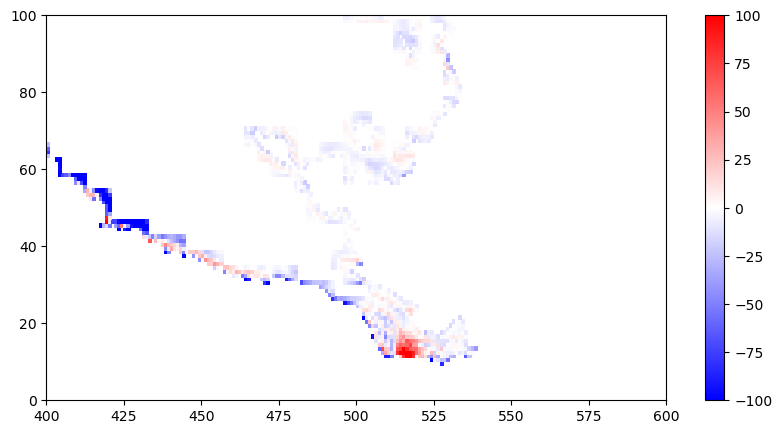

In [12]:
variable = 'bathymetry'
fig, ax = plt.subplots(1,1, figsize = (10,5))
cmax = np.max((-np.nanmin(old_geomvars[variable].values - new_geomvars[variable].values),
    np.nanmax(old_geomvars[variable].values - new_geomvars[variable].values)))
plt.pcolor(old_geomvars[variable] - new_geomvars[variable], cmap = 'bwr')
plt.colorbar()
plt.clim(-cmax, cmax)
plt.clim(-100,100)

plt.xlim(600,800)
plt.ylim(200,300)

plt.xlim(400,600)
plt.ylim(0,100)

In [13]:
perc_diff = (-np.nansum(old_mask.closed_cavities_nan.values * old_geomvars.areas.values)/1e6 +\
np.nansum(new_mask.closed_cavities_nan.values * new_geomvars.areas.values * new_geomvars.fraction.values)/1e6) /\
(np.nansum(old_mask.closed_cavities_nan.values * old_geomvars.areas.values)/1e6)
print('Percentage difference to old mask: {:.1f}%'.format(perc_diff*100))

Percentage difference to old mask: 11.9%


In [14]:
# So the new mask has an area which is 11% larger than the old area?
# But somehow is doubling the melt???

(0.0, 100.0)

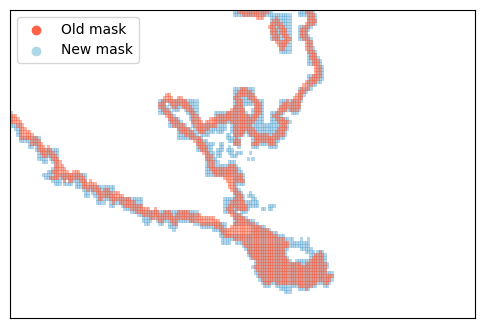

In [17]:
fig, ax = plt.subplots(1,1,figsize = (6,4))
im0 = plt.pcolor(new_mask.closed_cavities_nan, cmap = 'Blues', alpha = 0.5)
im = plt.pcolor(old_mask.closed_cavities_nan, alpha = 0.5, cmap = 'Reds', zorder = 1)
im.set_clim(0.5,1.5)
im0.set_clim(0.5,1.5)
ax.scatter(0,0, color = 'tomato', label = 'Old mask')
ax.scatter(0,0, color = 'lightblue', label = 'New mask')
ax.legend(loc = 2)
#plt.colorbar(im0)
ax.set_xticks([]); ax.set_yticks([]);

plt.xlim(400,600)
plt.ylim(0,100)

#plt.xlim(600,800)
#plt.ylim(200,300)

#plt.xlim(830,930)
#plt.ylim(200,400)

#plt.xlim(1050,1250)
#plt.ylim(200,300)

#plt.xlim(1400,1450)
#plt.ylim(200,350)

# A more in depth look at what is happening in the apply_nn_to_NEMO function

### Load in the NEMO data, masks associated, and the target grid for the NN

In [18]:
filepath_nemo_output = '/bettik/ockendeh/NEMO_simulations/test_data/gridT_1979.nc'
filepath_nemo_output = '/bettik/ockendeh/SCRIPTS/simpleNN_basal_melt/AIAI_data/ECM71-ico-LR-pi-01.pi_1883_1Y_grid_T.nc'

In [19]:
def load_setup(filepath_nemo_output, fp_geomvars, fp_mask, join_ice_shelves):
    # Load in the TS grid 
    gridT2 = load_TSmelt_normal(filepath_nemo_output)
    # Load in the mask for the ocean region 
    bmach_masks = xr.open_dataset(filepath_eORCA1_bmach_masks)
    mask_nocavs = bmach_masks.mask_nocavs.values
    bmach_masks.close()
    
    # Load in the mask and geometry 
    masks, basins_merged, geoms = load_geom_files(fp_geomvars, 
                                                  fp_mask, 
                                                  join_ice_shelves = join_ice_shelves)
    
    # Rename the dimensions of basins merged to be x and y 
    if 'y_grid_T' in basins_merged.dims:
        basins_merged = basins_merged.rename({"y_grid_T": "y", "x_grid_T": "x"}).astype(int)
    # Load in the coordinates for the grid 
    coords = load_gridcoords(filepath_nemo_output)
    # The basins mask for the NEMO 025 grid  
    basins_NEMO = masks.basins_NEMO.values
    if join_ice_shelves == True:
        # Dotson and Crosson?
        #basins_NEMO[basins_NEMO == 101] = 129
        # Abbot Ice Shelf
        basins_NEMO[basins_NEMO == 109] = 143
        # George VI
        basins_NEMO[basins_NEMO == 112] = 125
        # Lambert 
        basins_NEMO[basins_NEMO == 20] = 103
    basin_nos = np.arange(1,156, dtype = 'float32')
    basin_nos = np.unique(basins_NEMO)
    return gridT2, masks, basins_merged, geoms, mask_nocavs, coords, basin_nos, basins_NEMO

In [20]:

def create_profiles(gridT2, masks, basins_merged, geoms, mask_nocav, coords, basin_nos, basins_NEMO):
    # Regions where it is acceptable to extract ocean profiles 
    iy, ix = np.where((mask_nocavs == 1))
    # coordinates of those cells
    lat_ocean = coords.nav_lat.values[iy, ix]
    lon_ocean = coords.nav_lon.values[iy, ix]
    # Transform to x and y
    transformer = Transformer.from_crs("epsg:4326","epsg:3031")
    x_ocean, y_ocean = transformer.transform(lat_ocean, lon_ocean)
    # Stack to prepare for the KDTree
    ocean_points = np.column_stack((x_ocean, y_ocean))
    # Create KDTree
    tree = cKDTree(ocean_points)

    # For each basin in basin_nos, create a mask of the ocean profiles to extract 
    profiles_all = []
    i_no_value = []
    area_basin = []
    basins_all_temp = np.zeros_like(mask_nocavs)
    for kk in range(len(basin_nos)):
        i = basin_nos[kk]
        mask_basin_cavs = (basins_NEMO == i) & (masks.closed_cavities == 1)
        # Extract these points 
        idx = np.where(mask_basin_cavs == 1)
        lat_cavs = masks.lat.values[idx]
        lon_cavs = masks.lon.values[idx]
        # Transform to x and y
        transformer = Transformer.from_crs("epsg:4326","epsg:3031")
        x_cavs, y_cavs = transformer.transform(lat_cavs, lon_cavs)
        # Stack cavity points to query KDTree
        cav_points = np.column_stack((x_cavs, y_cavs))
        dist, idx = tree.query(cav_points)
        # Same dimensions as the mask of the not cavities
        ocean_edge_basin = np.zeros_like(mask_nocavs)
        # And fill the cells found with the kd-tree
        # Should allow cells which are adjacent or as close to adjacent as possible
        if len(idx) == 1:
            for k in range(len(idx)):
                ocean_edge_basin[iy[idx[k]], ix[idx[k]]] = 1
        elif len(idx) != 0:
            idxn = np.unique(idx[dist < np.min(dist[dist != np.min(dist)]) * 2])
            for k in range(len(idxn)):
                ocean_edge_basin[iy[idxn[k]], ix[idxn[k]]] = 1
        else:
            # Calculate which basins don't have profiles
            i_no_value.append(int(i))
        ### This is only needed if you want to look at which ocean cells will recieve melt from many basins   
        basins_all_temp = basins_all_temp + ocean_edge_basin
        
        # Use the mask to extract the relevant profiles 
        masked_depth = gridT2.where(ocean_edge_basin == 1)
        profiles = masked_depth.stack(points=("x", "y"))
        profiles = profiles.dropna(dim="points", how="all")
        #profiles = profiles.drop_vars(["area", "bathy", "isf_draft"]) 
        # Fill the nan values in the profile
        profile_kk = profiles.mean(dim = 'points').interpolate_na(dim = 'deptht').ffill('deptht').bfill('deptht')
        # Add a coordinate for kk
        profile_kk = profile_kk.expand_dims(kk =[int(i)])
        #profile_kk = profile_kk.expand_dims(kk_m1 =[int(i)-1])
        profiles_all.append(profile_kk)
        if verbose == 1:
            print('{} out of {} profiles processed'.format(kk+1, len(basin_nos)), end = '\r')
    # Concatenate the profiles along the new dimension
    all_profiles = xr.concat(profiles_all, dim="kk")
    
    print('There are {} basins with no ocean profiles : {}'.format(len(i_no_value), i_no_value))
    #print('There should be 17 basins (14 with no cavities plus 3 where we merged)')
    return all_profiles

In [21]:
plot_profile = False
if plot_profile == True:
    fig, ax = plt.subplots(1,2, figsize = (10,4))
    for kk in all_profiles.kk.values:
        profile = all_profiles.sel(kk=kk)
        ax[0].plot(profile.thetao, -profile.deptht, c = plt.cm.viridis(kk/np.max(all_profiles.kk.values)))
        ax[1].plot(profile.so, -profile.deptht, c = plt.cm.viridis(kk/np.max(all_profiles.kk.values)))
    ax[0].set_ylabel('Depth (m)');
    #ax[1].set_ylabel('Depth (m)')
    ax[0].set_xlabel('Temperature ($^{\\circ}$C)');
    ax[1].set_xlabel('Salinity (g/kg)');
    fig.savefig('profile.jpg', dpi = 200, bbox_inches = 'tight')

In [22]:
def create_dataset_for_NN(all_profiles, geoms):
    # Extract the relevant values of temperature and salinity 
    temp_xy = all_profiles.thetao.interp(deptht = geoms.isf_draft).sel(kk=basins_merged)
    temp_xy = temp_xy.reset_coords(drop=True)
    sals_xy = all_profiles.so.interp(deptht = geoms.isf_draft).sel(kk=basins_merged)
    sals_xy = sals_xy.reset_coords(drop=True)
    
    # Calculate mean and standard deviation by region
    # Note: this step produces an error because some basins have nan mean, but the code still runs so it's okay?
    meanT_by_region = temp_xy.groupby(basins_merged).mean()
    stdT_by_region  = temp_xy.groupby(basins_merged).std()
    meanS_by_region = sals_xy.groupby(basins_merged).mean()
    stdS_by_region  = sals_xy.groupby(basins_merged).std()
    # and send back to the original grid 
    mean_T = meanT_by_region.sel(basins_NEMO = basins_merged)
    std_T = stdT_by_region.sel(basins_NEMO = basins_merged)
    mean_S = meanS_by_region.sel(basins_NEMO = basins_merged)
    std_S = stdS_by_region.sel(basins_NEMO = basins_merged)
    # Reset the coordinates
    mean_T = mean_T.reset_coords(drop=True)
    mean_S = mean_S.reset_coords(drop=True)
    std_T = std_T.reset_coords(drop=True)
    std_S = std_S.reset_coords(drop=True)

    # Create the input dataset for the neural network to be applied to
    ds = geoms.rename({"areas": "area",
                       "isf_draft": "corrected_isdraft",
                       "slope_isdraft_lon": "slope_is_lon",
                       "slope_isdraft_lat": "slope_is_lat",
                       "slope_bathy_lon": "slope_ba_lon",
                       "slope_bathy_lat": "slope_ba_lat",})
    ds = ds.assign(temperature_prop = temp_xy,
                      mean_T           = mean_T,
                      std_T            = std_T,
                      salinity_prop    = sals_xy,
                      mean_S           = mean_S,
                      std_S            = std_S,
                      basins_NEMO      = basins_merged,)
    ds.attrs["description"] = "Neural network input variables"

    # Rename variables in closed cavity mask 
    try:
        closed_cavs = masks.closed_cavities_nan.rename({"y_grid_T": "y", "x_grid_T": "x"})
    except:
        closed_cavs = masks.closed_cavities_nan
    #closed_cavs = masks.closed_cavities_nan.rename({"y_grid_T": "y", "x_grid_T": "x"})
    # Select only the points in the closed cavity regions
    stacked = ds.where(closed_cavs == 1).stack(points=("x", "y")).dropna("points", how = "all")
    # and convert to a pandas dataframe
    selected = stacked.to_dataframe().reset_index().drop(columns=["x", "y"])
    # Remove nan values (although still unclear why there are nan values)
    selected = selected[~np.isnan(selected.temperature_prop)]
    return selected

In [23]:
plot_figure = False
if plot_figure == True:
    fig, ax = plt.subplots(1,2, figsize = (10,4))
    try:
        closed_cavs = masks.closed_cavities_nan.rename({"y_grid_T": "y", "x_grid_T": "x"})
    except:
        closed_cavs = masks.closed_cavities_nan#.rename({"y_grid_T": "y", "x_grid_T": "x"})
    im = [[],[]]
    # Note that using pcolor rather than pcolormesh leads to the error
    im[0] = ax[0].pcolor(temp_xy*closed_cavs)
    im[1] = ax[1].pcolor(sals_xy*closed_cavs)
    labels = 'Temperature', 'Salinity'
    for i in range(2):
        ax[i].set_xticks([])
        ax[i].set_yticks([])
        cbar = plt.colorbar(im[i], ax = ax[i], orientation = 'horizontal', pad = 0.01, shrink = 0.5)
        cbar.set_label(labels[i])
    fig.savefig('Propagated.jpg',dpi= 200, bbox_inches = 'tight')

In [24]:
def apply_10nns(exp_name, this_collection, clean_df, path_model, path_norm_metrics, 
                       mod_size = 'small', 
                         TS_opt = 'extrap', 
                    norm_method = 'std', 
                        verbose = 0, 
                    annual_only = False, 
               apply_collection = None, 
                       annual_f = ''):
    # Load in the normalisation metrics 
    norm_metrics = load_normalisation_metrics(this_collection, path_norm_metrics, norm_method = 'std', verbose = 0)
    # Extract the values that you might want from the clean dataframe
    df_pred = pd.DataFrame({'lat'   : clean_df.lat, 
                            'lon'   : clean_df.lon,
                            'basin' : clean_df.basins_NEMO,
                            'area'  : clean_df.area, 
                            'fraction' : clean_df.fraction})
    seed_nb_array = np.arange(1,11,1)
    list_melt_seeds = []
    start_time = time.time()
    for i in range(len(seed_nb_array)):
        list_melt_seeds.append('melt_' + str(i+1).zfill(2))
    
        model = load_model_nn(exp_name, this_collection, path_model, seed_nb_array[i], \
                                  mod_size = mod_size, TS_opt = TS_opt, norm_method = norm_method, \
                                  verbose = verbose, annual_f = annual_f) 
        df_pred['melt_' + str(i+1).zfill(2)] = apply_model(model, norm_metrics, clean_df, exp_name, verbose = verbose)
        end_time = time.time()
        print(seed_nb_array[i], 'out of', len(seed_nb_array), 'processed. Time: {:.1f} s'.format(end_time - start_time), end = '\r')
    # Calculate the ensemble mean 
    df_pred['mean_melt'] = np.mean(df_pred[list_melt_seeds], axis = 1).values
    if verbose == 1:
        print('Maximum melt rate: {:.5f} '.format(np.min(df_pred.mean_melt.values)))
        print('Minimum melt rate: {:.5f} '.format(np.max(df_pred.mean_melt.values)))
        print('Mean melt rate: {:.5f} '.format(np.mean(df_pred.mean_melt.values)))
    # And the standard deviation 
    df_pred['std_melt'] = np.std(df_pred[list_melt_seeds], axis = 1).values
    #df_pred.loc[:,'melt_Gt'] = df_pred.mean_melt * (60*60*24*365.25)/917
    df_pred.loc[:,'melt_Gt'] = df_pred.mean_melt * df_pred.area * 31536000 * 1/1e12 * df_pred.fraction 
    # Save just the ensemble mean/std
    #df_save = df_pred.copy()[['lat','lon', 'basin', 'area', 'mean_melt', 'std_melt', 'melt_Gt']]
    # Save just the melt by basin/
    melt = df_pred
    transformer = Transformer.from_crs("epsg:4326","epsg:3031")
    melt['x'], melt['y'] = transformer.transform(melt.lat, melt.lon)
    melt_by_basin = df_pred.groupby('basin', as_index = False).sum()[['basin','melt_Gt']]
    #lat_lon_by_basin = df_pred.groupby('basin', as_index = False).mean()[['lat','lon']]
    return melt, melt_by_basin

In [25]:
def put_melt_into_geoms_frame(geoms, all_vals_melt):
    ds = geoms.copy()
    # Flatten the grid coordinates and indices
    y_idx, x_idx = np.indices(ds.lat.shape)
    lookup = pd.DataFrame({
        "lat": ds.lat.values.ravel(),
        "lon": ds.lon.values.ravel(),
        "y_idx": y_idx.ravel(),
        "x_idx": x_idx.ravel(),
    })
    # Match dataframe rows to grid cells
    matched = all_vals_melt.merge(lookup, on=["lat", "lon"], how="left")
    # Create output grid
    melt_grid = np.full(ds.lat.shape, np.nan)
    # Populate grid
    melt_grid[matched["y_idx"].astype(int), matched["x_idx"].astype(int)] = matched["melt_Gt"].values
    # Put back into xarray
    ds["melt"] = (("y", "x"), melt_grid)
    return ds

### APPLY these functions to calculate melt in different situations 

In [26]:
verbose = 2

#filepath_nemo_output 
fp_geomvars = filepath_geomvars
fp_mask = filepath_mask
# join_ice_shelves 
#fp_geomvars = fp_old_geomvars
#fp_mask = fp_old_mask

gridT2, masks, basins_merged, geoms, mask_nocavs, coords, basin_nos, basins_NEMO = \
                        load_setup(filepath_nemo_output, fp_geomvars, fp_mask, join_ice_shelves)
all_profiles = create_profiles(gridT2, masks, basins_merged, geoms, mask_nocavs, coords, basin_nos, basins_NEMO)
selected = create_dataset_for_NN(all_profiles, geoms)
melt, melt_by_basin = apply_10nns(exp_name, this_collection, selected.to_xarray(), path_model, path_norm_metrics)
print('Total melt:', np.sum(-melt.melt_Gt))
gmelt = put_melt_into_geoms_frame(geoms, melt)

You have loaded T and S: /bettik/ockendeh/SCRIPTS/simpleNN_basal_melt/AIAI_data/ECM71-ico-LR-pi-01.pi_1883_1Y_grid_T.nc
Cropped to Antarctica only
You have loaded: /bettik/ockendeh/NEMO_simulations/NEMO025_bmach_geom_vars.nc
You have loaded: /bettik/ockendeh/NEMO_simulations/NEMO025_bmach_geometric_masks.nc
You have loaded coordinates: /bettik/ockendeh/SCRIPTS/simpleNN_basal_melt/AIAI_data/ECM71-ico-LR-pi-01.pi_1883_1Y_grid_T.nc
Cropped to Antarctica only
There are 0 basins with no ocean profiles : []
Total melt: 1619.720776243353614.1 s


In [59]:
verbose = 2

#filepath_nemo_output 
#fp_geomvars = filepath_geomvars
#fp_mask = filepath_mask
# join_ice_shelves 
fp_geomvars = fp_old_geomvars
#fp_geomvars = '/bettik/ockendeh/SCRIPTS/simpleNN_basal_melt/AIAI_data/Masks/OPM026_geom_vars_dists.nc'
#fp_geomvars = '/bettik/ockendeh/SCRIPTS/simpleNN_basal_melt/AIAI_data/Masks/OPM026_geom_vars_bathy.nc'
#fp_geomvars = '/bettik/ockendeh/SCRIPTS/simpleNN_basal_melt/AIAI_data/Masks/OPM026_geom_vars_isfdt.nc'
#fp_geomvars = '/bettik/ockendeh/SCRIPTS/simpleNN_basal_melt/AIAI_data/Masks/OPM026_geom_vars_bais.nc'
#fp_geomvars = '/bettik/ockendeh/SCRIPTS/simpleNN_basal_melt/AIAI_data/Masks/OPM026_geom_vars_bathy_dist.nc'
#fp_geomvars = '/bettik/ockendeh/SCRIPTS/simpleNN_basal_melt/AIAI_data/Masks/OPM026_geom_vars_isfdt_dist.nc'
#fp_geomvars = '/bettik/ockendeh/SCRIPTS/simpleNN_basal_melt/AIAI_data/Masks/OPM026_geom_vars_isfdt_bathy.nc'
#fp_geomvars = filepath_geomvars 
#fp_mask = fp_old_mask
fp_mask = filepath_mask

gridT2, masks, basins_merged, geoms2, mask_nocavs, coords, basin_nos, basins_NEMO = \
                        load_setup(filepath_nemo_output, fp_geomvars, fp_mask, join_ice_shelves)
all_profiles = create_profiles(gridT2, masks, basins_merged, geoms2, mask_nocavs, coords, basin_nos, basins_NEMO)
selected = create_dataset_for_NN(all_profiles, geoms2)
melt2, melt_by_basin2 = apply_10nns(exp_name, this_collection, selected.to_xarray(), path_model, path_norm_metrics)
print('Total melt:', np.sum(-melt2.melt_Gt))
gmelt2 = put_melt_into_geoms_frame(geoms2, melt2)

You have loaded T and S: /bettik/ockendeh/SCRIPTS/simpleNN_basal_melt/AIAI_data/ECM71-ico-LR-pi-01.pi_1883_1Y_grid_T.nc
Cropped to Antarctica only
You have loaded: /bettik/ockendeh/SCRIPTS/simpleNN_basal_melt/AIAI_data/Masks/OPM026_geom_vars_frac1.nc
You have loaded: /bettik/ockendeh/NEMO_simulations/NEMO025_bmach_geometric_masks.nc
You have loaded coordinates: /bettik/ockendeh/SCRIPTS/simpleNN_basal_melt/AIAI_data/ECM71-ico-LR-pi-01.pi_1883_1Y_grid_T.nc
Cropped to Antarctica only
There are 0 basins with no ocean profiles : []
Total melt: 826.7132888033466 9.2 s


In [60]:
mask_union = ~np.isnan(gmelt.melt.values) & ~np.isnan(gmelt2.melt.values)
np.nansum(gmelt.melt*mask_union), np.nansum(gmelt2.melt*mask_union)

(np.float64(-1238.6069465361672), np.float64(-826.7132888033466))

In [50]:
gmelt = put_melt_into_geoms_frame(geoms, melt)
gmelt2 = put_melt_into_geoms_frame(geoms2, melt2)

In [51]:
gmelt0 = gmelt.copy()
gmelt0 = gmelt0.melt.values
gmelt0[np.isnan(gmelt0)] = 0
gmelt20 = gmelt2.copy().melt.values
gmelt20[np.isnan(gmelt20)] = 0

In [52]:
gmelt = put_melt_into_geoms_frame(geoms, melt)
gmelt2 = put_melt_into_geoms_frame(geoms2, melt2)

In [53]:
print('Difference in cells which are in both masks:     {:.0f} Gt/yr'.format(np.nansum(((-gmelt.melt) - (-gmelt2.melt)).values))) 
print('Difference in cells which are in one masks only: {:.0f} Gt/yr'.format(\
    np.nansum((-gmelt0 --gmelt20)) - np.nansum(((-gmelt.melt) - (-gmelt2.melt)))))

Difference in cells which are in both masks:     341 Gt/yr
Difference in cells which are in one masks only: 381 Gt/yr


/tmp/ipykernel_1539418/1667539833.py:9: MatplotlibDeprecationWarning: Getting the array from a PolyQuadMesh will return the full array in the future (uncompressed). To get this behavior now set the PolyQuadMesh with a 2D array .set_array(data2d).
  cbar = plt.colorbar(im)


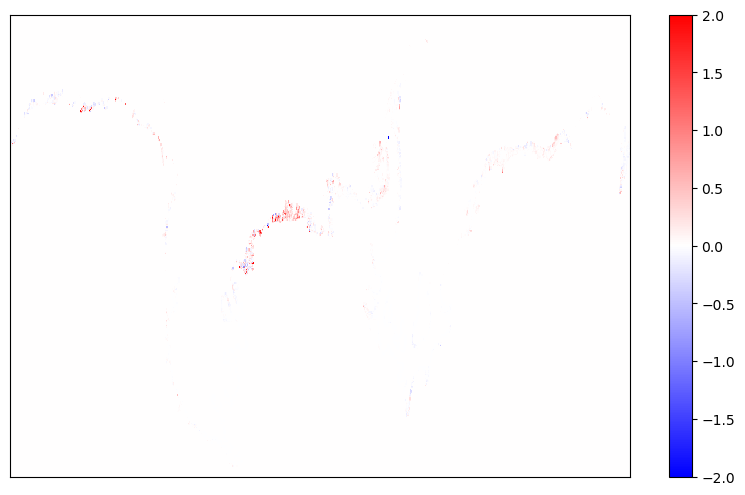

In [54]:
fig, ax = plt.subplots(1,1, figsize = (10,6))
im = plt.pcolor((-gmelt.melt) - (-gmelt2.melt), cmap = 'bwr')
#im.set_clim(-200000,200000)
im.set_clim(-2,2)

im2 = plt.pcolor(-gmelt0 + gmelt20, cmap = 'bwr', zorder = 0)
im2.set_clim(-2,2)

cbar = plt.colorbar(im)

#ax.set_xlim(600,800)
#ax.set_ylim(200,300)
ax.set_xticks([]); ax.set_yticks([]);
ax.set_ylim(0,400);
#ax.set_aspect(1)

In [ ]:
THW = melt[melt.basin == 105.0]# & melt.basin == 94.0 & melt.basin == 18]
print(-np.sum(THW.melt_Gt), np.sum(-melt.melt_Gt))

In [ ]:
fig, axs = plt.subplots(1,2, figsize = (10,5))
ds_plt = THW
im = [[],[],[]]
ax = axs
#im[0] = axs[0].scatter(ds_plt.x, ds_plt.y, c = -ds_plt.mean_melt, s = 10, cmap = 'coolwarm')
im[0] = axs[0].scatter(ds_plt.x, ds_plt.y, c = -ds_plt.mean_melt/917 * (60*60*24*365.35), s = 10, cmap = 'bwr')
im[0].set_clim(np.min(ds_plt.mean_melt/917 * (60*60*24*365.35)), -np.min(ds_plt.mean_melt/917 * (60*60*24*365.35)))
im[1] = axs[1].scatter(ds_plt.x, ds_plt.y, c = -ds_plt.melt_Gt, s = 10, cmap = 'Reds')
#im[1].set_clim(np.min(ds_plt.melt_Gt), -np.min(ds_plt.melt_Gt))
labels = 'Melt rate (m/yr)','Melt rate (Gt/yr)'
for i in range(2):
    cbar = plt.colorbar(im[i], ax = axs[i], orientation = 'horizontal', pad = 0, shrink = 0.5)
    #ax.yaxis.set_ticks_position('left')
    cbar.set_label(labels[i])
    axs[i].axis('off');
    axs[i].set_aspect(1)
axs[1].annotate('Total melt: {:.0f} Gt'.format(-np.sum(THW.melt_Gt)), \
                xy = (0,0), xytext = (0.25, 0.05), xycoords = ('axes fraction'))
axs[0].annotate('Mean melt rate:\n{:.1f} m/yr'.format(-np.mean(THW.mean_melt)/917 * (60*60*24*365.25)), \
                xy = (0,0), xytext = (0.25, 0.05), xycoords = ('axes fraction'))
axs[0].set_title('George VI Ice shelf', fontweight = 'bold');

In [ ]:
filepath_flx = '/bettik/ockendeh/NEMO_simulations/test_data/flxT_1979.nc'
flx = xr.open_dataset(filepath_flx)

In [ ]:
flx = flx.isel(time_counter = 0)

In [ ]:
flx

In [ ]:
flx_x, flx_y = transformer.transform(flx.nav_lat.values, flx.nav_lon.values)

In [ ]:
mask = ~np.isnan(flx.sowflisf_cav.values)
np.nansum(flx.sowflisf_cav.values * flx.area * 31536000 * 1/1e12)

# So NEMO has total 725 Gt of melt 

In [ ]:
fig, ax = plt.subplots(1,1, figsize = (7,5))
#ax.axis('off');
ax.set_xticks([]); ax.set_yticks([]);
im = plt.scatter(melt.x, melt.y, c = -melt.mean_melt / 917 * (60*60*24*365.25), s = 0.01, cmap = 'coolwarm')
print(-np.min(melt.mean_melt), -np.max(melt.mean_melt))
im.set_clim(np.nanmin(melt.mean_melt/ 917 * (60*60*24*365.25)),-np.nanmin(melt.mean_melt/ 917 * (60*60*24*365.25)))
#im.set_clim(-4,4)
#ax.set_xlim(-2e6,-1.3e6)
#ax.set_ylim(-1e6,0e6)
ax.set_aspect(1)
cbar = plt.colorbar(im, shrink = 0.5, pad = 0.01)
cbar.set_label('Melt (m/yr)')

#im2 = plt.scatter(flx_x[mask], flx_y[mask], c = flx.sowflisf_cav.values[mask]/ 917 * (60*60*24*365.25), s = 100, cmap = 'coolwarm', zorder = 0)
#im2.set_clim(np.nanmin(melt.mean_melt/ 917 * (60*60*24*365.25)),-np.nanmin(melt.mean_melt/ 917 * (60*60*24*365.25)))

im.set_clim(-25,25)
#im2.set_clim(-5,5)

#ax.set_xlim()

# Amery Ice shelf 
#ax.set_xlim(1.6e6,2.3e6)
#ax.set_ylim(0.5e6,1e6)

# A random part of Filcher/Ronne
#ax.set_xlim(-0.75e6,-0.5e6)
#ax.set_ylim(0.5e6,0.75e6)

# A different bit of F/R 
#ax.set_xlim(-1.5e6,-1.0e6)
#ax.set_ylim(0.1e6,0.6e6)

#im.set_clim(0,100)

In [ ]:
masks

In [ ]:
# Due to some weird naming conventions in legacy files 
try:
    masks = masks.rename({"y_grid_T": "y", "x_grid_T": "x"})
except:
    masks = masks

masked_lat = masks.lat.where(masks.closed_cavities == 1)
masked_lon = masks.lon.where(masks.closed_cavities == 1)

mean_lat = masked_lat.groupby(masks.basins_NEMO).mean()
mean_lon = masked_lon.groupby(masks.basins_NEMO).mean()

mean_bybasin = xr.Dataset({
    "mean_lat": mean_lat,
    "mean_lon": mean_lon
})
mean_bybasin = mean_bybasin.rename({'basins_NEMO':'basin'})

df_coords = mean_bybasin.to_dataframe().reset_index()
df_merged = df_coords.merge(melt_by_basin, on="basin")
transformer = Transformer.from_crs("epsg:4326","epsg:3031")
df_merged['x'], df_merged['y'] = transformer.transform(df_merged.mean_lat, df_merged.mean_lon)

In [ ]:
fig, ax = plt.subplots(1,1, figsize = (7,4))
im = [[],[]]
im[0] = plt.scatter(df_merged.x, df_merged.y, c = -df_merged.melt_Gt, cmap = 'coolwarm')
#im[1] = plt.scatter(df_merged.x, df_merged.y, c = np.log10(df_merged.melt_Gt), cmap = 'Blues')
ax.axis('off');
plt.colorbar(im[0], shrink = 0.4)
#plt.colorbar(im[1], shrink = 0.4)
#im[0].set_clim(-200,200)
#im[1].set_clim(-1.1,2.1)

In [ ]:
fig, ax = plt.subplots(1,1, figsize = (7,4))
im = [[],[]]
im[0] = plt.scatter(df_merged.x, df_merged.y, c = np.log10(-df_merged.melt_Gt), cmap = 'Reds')
im[1] = plt.scatter(df_merged.x, df_merged.y, c = np.log10(df_merged.melt_Gt), cmap = 'Blues')
ax.axis('off');
plt.colorbar(im[0], shrink = 0.4)
plt.colorbar(im[1], shrink = 0.4)
im[0].set_clim(-1.1,2.1)
#im[1].set_clim(-1.1,2.1)

In [ ]:
fig, ax = plt.subplots(1,1, figsize = (20,5))
plt.plot(melt_by_basin.basin, melt_by_basin.melt_Gt)
#plt.xlim(98,100)

In [ ]:
#plt.pcolor(areas)
basins_NEMO.shape, masks.closed_cavities.shape

In [ ]:

areas = load_area(filepath_nemo_output)
melt_all = np.zeros_like(mask_nocavs)
melt_b = np.zeros_like(mask_nocavs)
melt_t = np.zeros_like(mask_nocavs)
print('Putting melt back onto the ocean grid')
for kk in range(len(melt_by_basin.basin)):
    i = melt_by_basin.basin[kk]
    mask_basin_cavs = (basins_NEMO == i) & (masks.closed_cavities == 1)
    # Calculate the top and bottom depths to inject the melt 
    # Currently using means, but might be better to use a min/max? ideally at cells touching the ocean 
    melt_b_basin = np.mean(geoms.bathymetry.values[mask_basin_cavs == 1])
    melt_t_basin = np.mean(geoms.isf_draft.values[mask_basin_cavs == 1])
    # Extract these points 
    idx = np.where(mask_basin_cavs == 1)
    lat_cavs = masks.lat.values[idx]
    lon_cavs = masks.lon.values[idx]
    # Transform to x and y
    transformer = Transformer.from_crs("epsg:4326","epsg:3031")
    x_cavs, y_cavs = transformer.transform(lat_cavs, lon_cavs)
    # Stack cavity points to query KDTree
    cav_points = np.column_stack((x_cavs, y_cavs))
    dist, idx = tree.query(cav_points)
    # Same dimensions as the mask of the not cavities
    ocean_edge_basin = np.zeros_like(mask_nocavs)
    # And fill the cells found with the kd-tree
    # Should allow cells which are adjacent or as close to adjacent as possible
    if len(idx) == 1:
        for k in range(len(idx)):
            ocean_edge_basin[iy[idx[k]], ix[idx[k]]] = 1
    elif len(idx) != 0:
        idxn = np.unique(idx[dist < np.min(dist[dist != np.min(dist)]) * 2])
        for k in range(len(idxn)):
            ocean_edge_basin[iy[idxn[k]], ix[idxn[k]]] = 1
    # Redistribute the melt over the relevant cells
    # Number of pixels?
    #pixels = np.sum(ocean_edge_basin)
    # Total area covered 
    ocean_area = np.sum(areas * ocean_edge_basin).data
    # Melt per pixel?? 
    melt_per_pixel = melt_by_basin.melt_Gt[kk] * (10e12/(60*60*24*365.5)) /ocean_area
    ocean_melt = ocean_edge_basin * melt_per_pixel
    # Apply top and bottom over the relevant cells
    ocean_melt_b = ocean_edge_basin * melt_b_basin
    ocean_melt_t = ocean_edge_basin * melt_t_basin
    # Sum up the melt over all the basins
    melt_all = melt_all + ocean_melt
    melt_b = melt_b + ocean_melt_b
    melt_t = melt_t + ocean_melt_t
    print('{} out of {} profiles processed'.format(kk+1, len(basin_nos)), end = '\r')

In [ ]:
melt_by_basin.melt_Gt[melt_by_basin.melt_Gt > 0]

In [ ]:
# Expanding the grid back to the NEMO eORCA1 grid
# gridT_varofint = xr.open_dataset('/ccc/work/cont003/gen6035/ockendeh/NEMO/eORCA1.L75/eORCA1.L75-I/eORCA1.4.3_CavsForNN_domain_cfg.nc')[['x','y']]
gridT_varofint = xr.open_dataset(filepath_nemo_output)[['x','y']]
min_lat = -52.2
y_trim = np.max(np.argwhere(gridT_varofint.nav_lat[:,0].data <= min_lat))
full_t   = expand_to_full_grid(melt_t,    y_trim, gridT_varofint)
full_b   = expand_to_full_grid(melt_b,    y_trim, gridT_varofint)
full_all = expand_to_full_grid(melt_all,  y_trim, gridT_varofint)

if nemo_version == '5':
    # In NEMO 5 the melt convention has changed
    # Melting is now positive and refreezing is now negative 
    print('New NEMO version (v{}), melt is positive'.format(nemo_version))
    full_all = full_all * -1 
else:
    # In NEMO 4 the melt convention is the same as in Pierre's simulations
    print('Old NEMO version (v{}), melt is negative'.format(nemo_version))
    full_all = full_all 

In [ ]:
# Create a netcdf dataset for the temperature and salinity profiles 
output_melt = xr.Dataset(data_vars=dict(
                                melt      = (["y", "x"], full_all.data), 
                                melt_top  = (["y", "x"], full_t.data),
                                melt_base = (["y", "x"], full_b.data),
                              ),
                   coords=dict(
                               lon = (("y", "x"), full_all.nav_lon.data),
                               lat = (("y", "x"), full_all.nav_lat.data),    
                              ),
                    attrs=dict(
                               description    = "Neural network output", 
                               simulation_run = simulation, 
                               year           = year_of_interest, 
                               history        = f"{time.ctime()}: Applied neural network"),
                        )     

output_melt = output_melt.fillna(0)
print('Nan values filled')

output_melt["melt"].attrs.update({"standard_name": "Sub-shelf melt for parameterised regions",
                                  "units": "kg m-2 s-1"})
output_melt["melt_top"].attrs.update({"standard_name": "Top level to inject melt",
                                     "units": "m"})
output_melt["melt_base"].attrs.update({"standard_name": "Bottom level to inject melt",
                                     "units": "m"})
output_melt["lat"].attrs.update({"standard_name": "Latitude",
                                 "units": "degrees_north"})
output_melt["lon"].attrs.update({"standard_name": "Longitude",
                                 "units": "degrees_east"})

# Export to netcdf 
simulation = 'DUM003' # Can potentially be set from the input 
year_of_interest = '9999' # Can potentially be set from the input 

filepath_this_nn_output = filepath_nn_output + 'nn_output_melt' '_' + simulation + '_' + year_of_interest + '.nc'
output_melt.to_netcdf(filepath_this_nn_output)
print('You have saved the nn output to:', filepath_this_nn_output)

In [ ]:
melt = xr.open_dataset(filepath_this_nn_output)# + 'nn_output_melt' '_' + simulation + '_' + year_of_interest + '.nc')
melt_all = melt.melt.values
melt_all[melt_all == 0] = np.nan
print(np.nanmax(melt_all), np.nanmin(melt_all))

fig, ax = plt.subplots(1,1, figsize = (15,5))
im = plt.pcolor(np.log10(-melt_all), cmap = 'Blues')
im.set_clim(-5.25,-1.75)
cbar = plt.colorbar(im, ax= ax, pad = -0.08)
cbar.set_ticks((-5,-4,-3,-2))
cbar.set_ticklabels((('10$^{-5}$'), ('10$^{-4}$'), ('10$^{-3}$'), ('10$^{-2}$')))
im = plt.pcolor(np.log10(melt_all), cmap = 'Reds')
im.set_clim(-5.25,-1.75)
cbar = plt.colorbar(im, ax= ax, pad = 0)
cbar.set_ticks((-5,-4,-3,-2))
cbar.set_ticklabels((('10$^{-5}$'), ('10$^{-4}$'), ('10$^{-3}$'), ('10$^{-2}$')))

ax.set_xticks([]);
ax.set_yticks([]);
ax.set_ylim(0,110)

#im.set_clim(-0.1,0)
fig.savefig('Output melt.jpg', dpi = 200, bbox_inches = 'tight')